# Combinatorial Optimization with Physics-Inspired Graph Neural Networks

In this notebook we show how to solve combinatorial optimization problems with physics-inspired graph neural networks, as outlined in M. J. A. Schuetz, J. K. Brubaker, H. G. Katzgraber, _Combinatorial Optimization with Physics-Inspired Graph Neural Networks_, [arXiv:2107.01188](https://arxiv.org/abs/2107.01188).
Here we focus on the canonical maximum independent set (MIS) problem, but our approach can easily be extended to other combinatorial optimization problems.
For the actual implementation of the graph neural network we use the open-source ```dgl``` library.

Please note we have provided a `requirements.txt` file, which defines the environment required to run this code. Because some of the packages are not available on default OSX conda channels, we have also provided suggested channels to find them on. These can be distilled into a single line as such:

> conda create -n \<environment_name\> python=3 --file requirements.txt -c conda-forge -c dglteam -c pytorch

In [1]:
import dgl
import torch
import random
import os
import glob
import numpy as np
import networkx as nx
import torch.nn as nn
import torch.nn.functional as F

from collections import OrderedDict, defaultdict
from dgl.nn.pytorch import GraphConv, SAGEConv
from itertools import chain, islice, combinations
# from networkx.algorithms.approximation.independent_set import maximum_independent_set as mis
from time import time

# MacOS can have issues with MKL. For more details, see
# https://stackoverflow.com/questions/53014306/error-15-initializing-libiomp5-dylib-but-found-libiomp5-dylib-already-initial
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

ModuleNotFoundError: No module named 'dgl'

In [ ]:
# fix seed to ensure consistent results

# Set GPU/CPU
TORCH_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.float32
print(f'Will use device: {TORCH_DEVICE}, torch dtype: {TORCH_DTYPE}')

Will use device: cuda, torch dtype: torch.float32


# Step 0 - Define utility functions

We first load a few general utility functions from ```utils.py``` before defining some helper functions specific to the MIS problem.

### General utilities

In [ ]:
# from utils import generate_graph, get_gnn, run_gnn_training, qubo_dict_to_torch, gen_combinations, loss_func

### Problem-specific (MIS/MaxCut) utilities

In [ ]:
# helper function to generate Q matrix for Maximum Independent Set problem (MIS)
def gen_q_dict_mis(nx_G, penalty=2):
    """
    Helper function to generate QUBO matrix for MIS as minimization problem.

    Input:
        nx_G: graph as networkx graph object (assumed to be unweigthed)
    Output:
        Q_dic: QUBO as defaultdict
    """

    # Initialize our Q matrix
    Q_dic = defaultdict(int)

    # Update Q matrix for every edge in the graph
    # all off-diagonal terms get penalty
    for (u, v) in nx_G.edges:
        Q_dic[(u, v)] = penalty

    # all diagonal terms get -1
    for u in nx_G.nodes:
        Q_dic[(u, u)] = -1

    return Q_dic


# Run classical MIS solver (provided by NetworkX)
def run_mis_solver(nx_graph):
    """
    helper function to run traditional solver for MIS.

    Input:
        nx_graph: networkx Graph object
    Output:
        ind_set_bitstring_nx: bitstring solution as list
        ind_set_nx_size: size of independent set (int)
        number_violations: number of violations of ind.set condition
    """
    # compare with traditional solver
    t_start = time()
    ind_set_nx = mis(nx_graph)
    t_solve = time() - t_start
    ind_set_nx_size = len(ind_set_nx)

    # get bitstring list
    nx_bitstring = [1 if (node in ind_set_nx) else 0 for node in sorted(list(nx_graph.nodes))]
    edge_set = set(list(nx_graph.edges))

    # Updated to be able to handle larger scale
    print('Calculating violations...')
    # check for violations
    number_violations = 0
    for ind_set_chunk in gen_combinations(combinations(ind_set_nx, 2), 100000):
        number_violations += len(set(ind_set_chunk).intersection(edge_set))

    return nx_bitstring, ind_set_nx_size, number_violations, t_solve


# Calculate results given bitstring and graph definition, includes check for violations
def postprocess_gnn_mis(best_bitstring, nx_graph):
    """
    helper function to postprocess MIS results

    Input:
        best_bitstring: bitstring as torch tensor
    Output:
        size_mis: Size of MIS (int)
        ind_set: MIS (list of integers)
        number_violations: number of violations of ind.set condition
    """

    # get bitstring as list
    bitstring_list = list(best_bitstring)

    # compute cost
    size_mis = sum(bitstring_list)

    # get independent set
    ind_set = set([node for node, entry in enumerate(bitstring_list) if entry == 1])
    edge_set = set(list(nx_graph.edges))

    print('Calculating violations...')
    # check for violations
    number_violations = 0
    for ind_set_chunk in gen_combinations(combinations(ind_set, 2), 100000):
        number_violations += len(set(ind_set_chunk).intersection(edge_set))

    return size_mis, ind_set, number_violations

In [ ]:
# MAXCUT

def gen_q_dict_maxcut_pos(nx_G, penalty=2):
    """
    Helper function to generate QUBO matrix for MaxCut as minimization problem.
    Input:
    Output:
    nx_6: graph as networkx graph object (assumed to be unweigthed)
    Q_dic: QUBO as defaultdict
    """
    # Initialize our 0Q matrix
    Q_dic = defaultdict(int)
    # Update Q matrix for every edge in the graph
    # all off-diagonal terms get penalty
    for (u, v) in nx_G.edges:
        Q_dic[(u, v)] = penalty
    # all diagonal terms get
    for u in nx_G.nodes:
        Q_dic[(u, u)] = -nx_G.degree(u)

    return Q_dic


def gen_q_dict_maxcut(nx_G, penalty=2):
    """
    Helper function to generate QUBO matrix for MaxCut as minimization problem.
    Input:
    Output:
    nx_6: graph as networkx graph object (assumed to be unweigthed)
    Q_dic: QUBO as defaultdict
    """
    # Initialize our 0Q matrix
    Q_dic = defaultdict(int)
    Adj = nx.adjacency_matrix(nx_G).toarray()
    # Update Q matrix for every edge in the graph
    # all off-diagonal terms get penalty
    for (u, v) in nx_G.edges:
        Q_dic[(u, v)] = penalty * nx_G[u][v]["weight"]
    # all diagonal terms get
    for u in nx_G.nodes:
        Q_dic[(u, u)] =  -Adj[u].sum() #-nx_G.degree(u)

    return Q_dic


def get_cut_edges(G):
    # print(list({d for u, v, d in G.edges(data='weight')}))
    weights = 0  # sorted(list({d for u, v, d in G.edges(data='weight')}))
    n_cut = 0
    # cut_edges_by_weights = dict(zip(weights, [list() for el in weights]))
    for u, v, d in G.edges(data='weight'):
        if G.nodes[u]['subset'] != G.nodes[v]['subset']:
            # cut_edges_by_weights[d].append((u, v))
            n_cut += 1
            weights += G[u][v]["weight"]
    # cut_edges_by_weights = [cut_edges_by_weights[weight] for weight in sorted(weights)]
    return n_cut, weights


def metrics(G, bitstring):
    membership_dict = dict(zip(G.nodes(), bitstring))
    nx.set_node_attributes(G, membership_dict, 'subset')
    n_cuts, sums = get_cut_edges(G)
    return n_cuts

# Step 1 - Main modules initialisation

In [ ]:
class SAGEResBlock(torch.nn.Module):

    def __init__(self, in_channels, out_channels, feat_drop=0.):
        super(SAGEResBlock, self).__init__()
        self.sage1 = SAGEConv(in_channels, out_channels, aggregator_type= 'mean', feat_drop=feat_drop, bias=False)
        self.bn1 = nn.BatchNorm1d(in_channels)
        self.sage2 = SAGEConv(in_channels, out_channels, aggregator_type='pool', feat_drop=feat_drop, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu = nn.LeakyReLU()

    def forward(self, graph, x, edge_weight=None):
        residual = x
        out1 = self.sage1(graph, x, edge_weight)
        out1 = self.bn1(out1)

        out2 = self.sage2(graph, x, edge_weight)
        out2 = self.bn2(out2)

        out = self.relu(out1 + out2)

        return out


class ResSAGE(torch.nn.Module):
    def __init__(self, in_feats, hidden_sizes, number_classes, dropout, device):
        super (ResSAGE, self).__init__()
        self.dropout_frac = dropout
        self.layers = nn.ModuleList()
        current_dim = in_feats
        self.relu = torch.nn.LeakyReLU()

        if isinstance(hidden_sizes, int):
            hidden_sizes = [hidden_sizes]

        for hdim in hidden_sizes:
            self.layers.append(SAGEResBlock(current_dim, hdim).to(device))
            self.layers.append(torch.nn.LeakyReLU())

            current_dim = hdim

        self.layers.append(SAGEConv(current_dim, number_classes, aggregator_type='mean').to(device))


    def forward(self, graph, h, h0, edge_weight=None):
        h = torch.cat([h, h0], 1)

        for i, (layer, norm) in enumerate(zip(self.layers[:-1][::2], self.layers[:-1][1::2])):
            h = layer(graph, h, edge_weight)
            h = norm(h)

        h = F.dropout(h, p=self.dropout_frac)
        h0 = self.layers[-1](graph, h, edge_weight)
        h = torch.sigmoid(h0)

        return h, h0 #torch.concat([h0, h], 1)


# GNN class to be instantiated with specified param values
class GCN_dev(nn.Module):
    def __init__(self, in_feats, hidden_size, number_classes, dropout, device):
        """
        Initialize a new instance of the core GCN model of provided size.
        Dropout is added in forward step.

        Inputs:
            in_feats: Dimension of the input (embedding) layer
            hidden_size: Hidden layer size
            dropout: Fraction of dropout to add between intermediate layer. Value is cached for later use.
            device: Specifies device (CPU vs GPU) to load variables onto
        """
        super(GCN_dev, self).__init__()

        self.dropout_frac = dropout
        self.conv1 = GraphConv(in_feats, hidden_size).to(device)
        self.conv2 = GraphConv(hidden_size, number_classes).to(device)

    def forward(self, g, inputs):
        """
        Run forward propagation step of instantiated model.

        Input:
            self: GCN_dev instance
            g: DGL graph object, i.e. problem definition
            inputs: Input (embedding) layer weights, to be propagated through network
        Output:
            h: Output layer weights
        """
        # input step
        h = self.conv1(g, inputs)
        h = torch.relu(h)
        h = F.dropout(h, p=self.dropout_frac)

        # output step
        h = self.conv2(g, h)
        h = torch.sigmoid(h)

        return h


# Generate random graph of specified size and type,
# with specified degree (d) or edge probability (p)
def generate_graph(n, d=None, p=None, graph_type='reg', random_seed=0):
    """
    Helper function to generate a NetworkX random graph of specified type,
    given specified parameters (e.g. d-regular, d=3). Must provide one of
    d or p, d with graph_type='reg', and p with graph_type in ['prob', 'erdos'].

    Input:
        n: Problem size
        d: [Optional] Degree of each node in graph
        p: [Optional] Probability of edge between two nodes
        graph_type: Specifies graph type to generate
        random_seed: Seed value for random generator
    Output:
        nx_graph: NetworkX OrderedGraph of specified type and parameters
    """
    if graph_type == 'reg':
        print(f'Generating d-regular graph with n={n}, d={d}, seed={random_seed}')
        nx_temp = nx.random_regular_graph(d=d, n=n, seed=random_seed)
    elif graph_type == 'prob':
        print(f'Generating p-probabilistic graph with n={n}, p={p}, seed={random_seed}')
        nx_temp = nx.fast_gnp_random_graph(n, p, seed=random_seed)
    elif graph_type == 'erdos':
        print(f'Generating erdos-renyi graph with n={n}, p={p}, seed={random_seed}')
        nx_temp = nx.erdos_renyi_graph(n, p, seed=random_seed)
    else:
        raise NotImplementedError(f'!! Graph type {graph_type} not handled !!')

    # Networkx does not enforce node order by default
    nx_temp = nx.relabel.convert_node_labels_to_integers(nx_temp)
    # Need to pull nx graph into OrderedGraph so training will work properly
    nx_graph = nx.OrderedGraph()
    nx_graph.add_nodes_from(sorted(nx_temp.nodes()))
    nx_graph.add_edges_from(nx_temp.edges)
    return nx_graph


# helper function to convert Q dictionary to torch tensor
def qubo_dict_to_torch(nx_G, Q, torch_dtype=None, torch_device=None):
    """
    Output Q matrix as torch tensor for given Q in dictionary format.

    Input:
        Q: QUBO matrix as defaultdict
        nx_G: graph as networkx object (needed for node lables can vary 0,1,... vs 1,2,... vs a,b,...)
    Output:
        Q: QUBO as torch tensor
    """

    # get number of nodes
    n_nodes = len(nx_G.nodes)

    # get QUBO Q as torch tensor
    Q_mat = torch.zeros(n_nodes, n_nodes)
    for (x_coord, y_coord), val in Q.items():
        Q_mat[x_coord][y_coord] = val

    if torch_dtype is not None:
        Q_mat = Q_mat.type(torch_dtype)

    if torch_device is not None:
        Q_mat = Q_mat.to(torch_device)

    return Q_mat


# Chunk long list
def gen_combinations(combs, chunk_size):
    yield from iter(lambda: list(islice(combs, chunk_size)), [])


def pagerank(nx_graph, feature_dim=10):
    features = torch.zeros((nx_graph.number_of_nodes(), feature_dim))
    pagerank = nx.pagerank(nx.Graph(nx_graph))
    for k, v in pagerank.items():
        features[k, :] = v
    return features


# helper function for custom loss according to Q matrix
def loss_func(probs, Q_mat, epoch=0):
    """
    Function to compute cost value for given probability of spin [prob(+1)] and predefined Q matrix.

    Input:
        probs: Probability of each node belonging to each class, as a vector
        Q_mat: QUBO as torch tensor
    """

    probs_ = torch.unsqueeze(probs, 1)
    lbd = epoch / 1e4
    # minimize cost = x.T * Q * x
    penalty = (probs - 1) * probs
    cost = (probs_.T @ Q_mat @ probs_).squeeze() + lbd * penalty.abs().sum()

    return cost


# Construct graph to learn on
def get_gnn(n_nodes, gnn_hypers, opt_params, torch_device, torch_dtype):
    """
    Generate GNN instance with specified structure. Creates GNN, retrieves embedding layer,
    and instantiates ADAM optimizer given those.

    Input:
        n_nodes: Problem size (number of nodes in graph)
        gnn_hypers: Hyperparameters relevant to GNN structure
        opt_params: Hyperparameters relevant to ADAM optimizer
        torch_device: Whether to load pytorch variables onto CPU or GPU
        torch_dtype: Datatype to use for pytorch variables
    Output:
        net: GNN instance
        embed: Embedding layer to use as input to GNN
        optimizer: ADAM optimizer instance
    """
    dim_embedding = gnn_hypers['dim_embedding']
    hidden_dim = gnn_hypers['hidden_dim']
    dropout = gnn_hypers['dropout']
    number_classes = gnn_hypers['number_classes']

    # instantiate the GNN
    net = ResSAGE(dim_embedding + 1 * number_classes + 4 * dim_embedding, hidden_dim, number_classes, dropout, torch_device)
    net = net.type(torch_dtype).to(torch_device)
    embed = nn.Embedding(n_nodes, dim_embedding)
    embed = embed.type(torch_dtype).to(torch_device)

    # set up Adam optimizer
    params = chain(net.parameters(), embed.parameters())
    optimizer = torch.optim.Adam(params, **opt_params)
    return net, embed, optimizer


# Parent function to run GNN training given input config
def run_gnn_training(q_torch, dgl_graph, net, embed, optimizer, number_epochs, tol, patience, prob_threshold):
    """
    Wrapper function to run and monitor GNN training. Includes early stopping.
    """
    # Assign variable for user reference
    edge_weight = (q_torch - torch.diag(q_torch.diag(0))) / 2
    edge_weight = edge_weight + edge_weight.T
    edge_weight = edge_weight[graph_dgl.edges()[0], graph_dgl.edges()[1]] #edge_weight.to_sparse_coo().values()

    # dgl_graph.edata

    inputs = torch.rand((dgl_graph.number_of_nodes(), 10), dtype=q_torch.dtype).to(q_torch.device)
    walk = pagerank(dgl_graph.cpu().to_networkx(), 2 * inputs.shape[1])
    inputs = torch.cat([inputs, torch.ones_like(inputs),  torch.ones_like(inputs), walk.to(q_torch.device)], 1)

    h0 = torch.zeros(dgl_graph.number_of_nodes(), 1).to(q_torch.device)

    prev_loss = 1.  # initial loss value (arbitrary)
    count = 0       # track number times early stopping is triggered
    best_epoch = 0
    best_sums = 0

    # initialize optimal solution
    best_bitstring = torch.zeros((dgl_graph.number_of_nodes(),)).type(q_torch.dtype).to(q_torch.device)
    best_loss = loss_func(best_bitstring.float(), q_torch)

    t_gnn_start = time()

    # Training logic
    for epoch in range(number_epochs):

        # get logits/activations
        # rand_part = torch.randn_like(h0) * torch.std(h0) + torch.mean(h0)
        probs, h0 = net(dgl_graph, inputs, h0.detach(), edge_weight)  # rand_part.detach())  #  collapse extra dimension output from model

        probs = probs.squeeze()

        # build cost value with QUBO cost function
        loss = loss_func(probs, q_torch, epoch)
        loss_ = loss.detach().item()

        # Apply projection
        bitstring = (probs.detach() >= prob_threshold) * 1
        if loss < best_loss:
            sums = -loss_func(bitstring.to(torch.float32), q_torch)
            if best_sums < sums:
                best_loss = max(loss, -sums)
                best_bitstring = bitstring
                best_probs = probs
                best_epoch = epoch
                best_sums = sums

        if epoch % 1000 == 0:
            print(f'Epoch: {epoch}, Loss: {loss_}, Best Loss: {best_loss}, Best sum: {best_sums}')

        # early stopping check
        # If loss increases or change in loss is too small, trigger
        if (abs(loss_ - prev_loss) <= tol) | ((loss_ - prev_loss) > 0):
            count += 1
        else:
            count = 0

        if count >= patience:
            print(f'Stopping early on epoch {epoch} (patience: {patience})')
            break

        # update loss tracking
        prev_loss = loss_

        # run optimization with backpropagation
        optimizer.zero_grad()  # clear gradient for step
        loss.backward()        # calculate gradient through compute graph
        nn.utils.clip_grad_norm_(net.parameters(), max_norm=2.0, norm_type=2)
        optimizer.step()       # take step, update weights

    t_gnn = time() - t_gnn_start
    print(f'GNN training (n={dgl_graph.number_of_nodes()}) took {round(t_gnn, 3)}')
    print(f'GNN final continuous loss: {loss_}')
    print(f'GNN best continuous loss: {best_loss}')

    final_bitstring = (probs.detach() >= prob_threshold) * 1

    return net, best_epoch, best_probs, best_bitstring, best_loss


# Step 2 - Set hyperparameters

In [ ]:
# # Graph hypers
# n = 100
# d = 3
# p = None
# graph_type = 'reg'

# # Problem size (e.g. graph size)
# n = 100

# NN learning hypers #
number_epochs = int(1e5)
learning_rate = 0.014
PROB_THRESHOLD = 0.5

# Early stopping to allow NN to train to near-completion
tol = 1e-4          # loss must change by more than tol, or trigger
patience = 100    # number early stopping triggers before breaking loop

# Establish dim_embedding and hidden_dim values
dim_embedding = 10 #int(np.sqrt(n))    # e.g. 10
hidden_dim = 51 #int(dim_embedding/2)  # e.g. 5

In [ ]:
# Constructs a random d-regular or p-probabilistic graph
# nx_graph = generate_graph(n=n, d=d, p=p, graph_type=graph_type, random_seed=seed_value)
# get DGL graph from networkx graph, load onto device
# graph_dgl = dgl.from_networkx(nx_graph=nx_graph)
# graph_dgl = graph_dgl.to(TORCH_DEVICE)

# # Construct Q matrix for graph
# q_torch = qubo_dict_to_torch(nx_graph, gen_q_dict_maxcut(nx_graph), torch_dtype=TORCH_DTYPE, torch_device=TORCH_DEVICE)

In [ ]:
# # Visualize graph
# pos = nx.kamada_kawai_layout(nx_graph)
# nx.draw(nx_graph, pos, with_labels=True, node_color=[[.7, .7, .7]])

# Step 3 - Set up optimizer/GNN architecture

# Step 4 - Run GNN training

In [ ]:
path = '..\qrf-gnn\Gset_neg'
res_folder = 'results_default_neg'

for file in glob.glob(os.path.join(path,'G13*')):
    print(file)

    nx_graph = nx.read_edgelist(file, nodetype=int, data=(('weight', float),))
    nx_graph = nx.to_undirected(nx_graph)
    mapping = dict(zip(nx_graph.nodes(), np.arange(nx_graph.number_of_nodes())))
    nx_graph = nx.relabel_nodes(nx_graph, mapping)
    graph_dgl = dgl.from_networkx(nx_graph=nx_graph)
    graph_dgl = graph_dgl.to(TORCH_DEVICE)

    n = nx_graph.number_of_nodes()

    # Construct Q matrix for graph
    q_torch = qubo_dict_to_torch(nx_graph, gen_q_dict_maxcut(nx_graph), torch_dtype=TORCH_DTYPE, torch_device=TORCH_DEVICE)

    stat = []
    best_loss = 0

    for s in range(1, 21):
        seed_value = s
        random.seed(seed_value)        # seed python RNG
        np.random.seed(seed_value)     # seed global NumPy RNG
        torch.manual_seed(seed_value)  # seed torch RNG

        # Establish pytorch GNN + optimizer
        opt_params = {'lr': learning_rate}
        gnn_hypers = {
            'dim_embedding': dim_embedding,
            'hidden_dim': hidden_dim,
            'dropout': 0.5,
            'number_classes': 1,
            'prob_threshold': PROB_THRESHOLD,
            'number_epochs': number_epochs,
            'tolerance': tol,
            'patience': patience
        }

        net, embed, optimizer = get_gnn(n, gnn_hypers, opt_params, TORCH_DEVICE, TORCH_DTYPE)

        # For tracking hyperparameters in results object
        gnn_hypers.update(opt_params)

        print('Running GNN...')
        gnn_start = time()

        _, epoch, final_bitstring, bitstring, loss = run_gnn_training(
            q_torch, graph_dgl, net, embed, optimizer, gnn_hypers['number_epochs'],
            gnn_hypers['tolerance'], gnn_hypers['patience'], gnn_hypers['prob_threshold'])

        if best_loss > loss:
            best_loss = loss
            best_bitstring = bitstring

        gnn_time = time() - gnn_start

        membership_dict = dict(zip(nx_graph.nodes(), best_bitstring))
        nx.set_node_attributes(nx_graph, membership_dict, 'subset')
        #print(nx_graph.edges(data='weight'))
        n_cuts, sums = get_cut_edges(nx_graph)
        stat.append([loss.detach().item(), n_cuts, gnn_time, epoch])

    if not os.path.exists(res_folder):
        os.mkdir(res_folder)

    with open(os.path.join(res_folder, 'results_' + file.split('\\')[-1]), 'a') as f:
        f.write('H;cuts;time_s;epoch\n')
        for elem in stat:
            f.write(';'.join(map(str, elem)) + '\n')

    with open(os.path.join(res_folder, 'best_solution_' + file.split('\\')[-1]), 'a') as f:
        f.write(' '.join(map(str, best_bitstring.detach().cpu().numpy())))

..\qrf-gnn\Gset_neg\G13.txt
Running GNN...
Epoch: 0, Loss: -14.626659393310547, Best Loss: -14.626659393310547, Best sum: 34.0
Epoch: 1000, Loss: -579.5191650390625, Best Loss: -564.0, Best sum: 564.0
Epoch: 2000, Loss: -577.2684326171875, Best Loss: -564.0, Best sum: 564.0
Epoch: 3000, Loss: -569.2197265625, Best Loss: -564.0, Best sum: 564.0
Epoch: 4000, Loss: -564.6326904296875, Best Loss: -564.0, Best sum: 564.0
Epoch: 5000, Loss: -551.0162963867188, Best Loss: -564.0, Best sum: 564.0
Epoch: 6000, Loss: -552.9522705078125, Best Loss: -564.0, Best sum: 564.0
Epoch: 7000, Loss: -548.2738037109375, Best Loss: -564.0, Best sum: 564.0
Epoch: 8000, Loss: -562.7300415039062, Best Loss: -564.0, Best sum: 564.0
Epoch: 9000, Loss: -559.331787109375, Best Loss: -564.0, Best sum: 564.0
Epoch: 10000, Loss: -554.0637817382812, Best Loss: -564.0, Best sum: 564.0
Epoch: 11000, Loss: -552.05859375, Best Loss: -564.0, Best sum: 564.0
Epoch: 12000, Loss: -557.9019165039062, Best Loss: -564.0, Best su

In [ ]:
import glob
import os
from matplotlib import pyplot as plt

%matplotlib inline

path = 'results_default/'
res_def = []

for file in glob.glob(os.path.join(path,'results*')):
    print(file)
    res_def.append([])
    with open(file, 'r') as f:
        f.readline()
        for _ in range(20):
            res_def[-1].append(-float(f.readline().split(';')[0]))

results_default\results_G15.txt
results_default\results_G22.txt
results_default\results_G50.txt
results_default\results_G55.txt


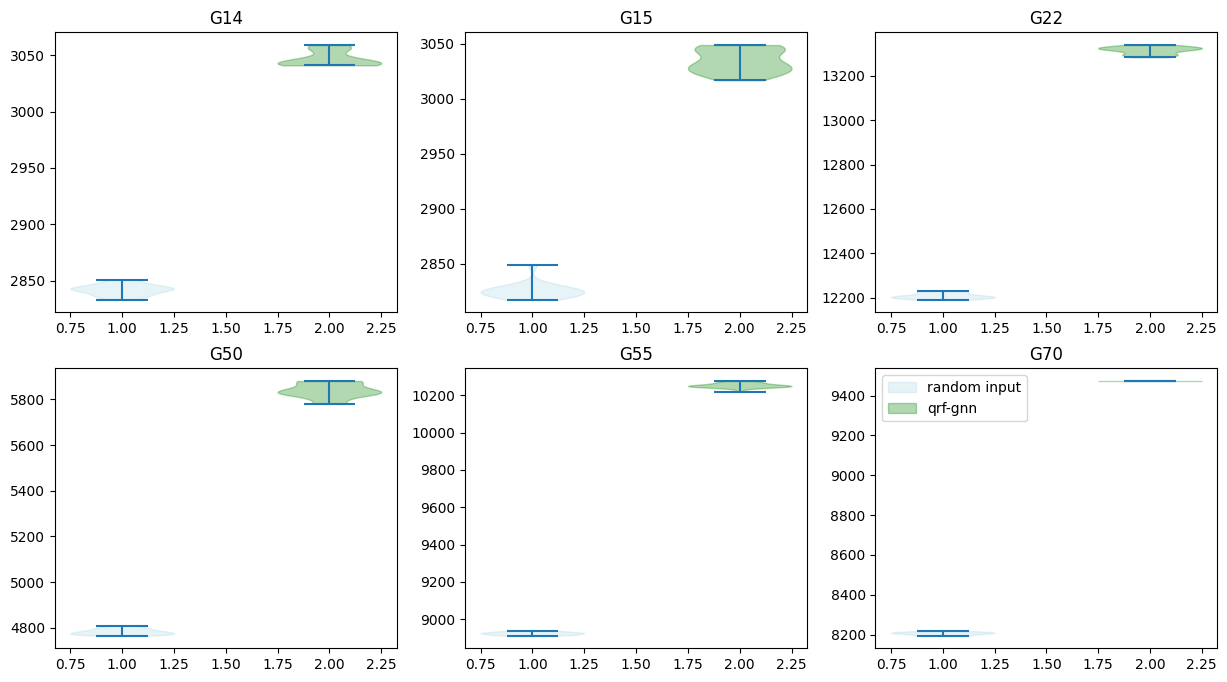

In [ ]:
# res.append(resg70 + [resg70[elem] for elem in [0, 2, 3, 8, 1, 10, 11]])
# res_def = [res_g14] + res_def + res_g70
names = ['G14', 'G15', 'G22', 'G50', 'G55', 'G70']
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
# res = [[-1 * elem for elem in res[i]] for i in range(len(res))]
colors = ['lightblue', 'green']
for i in range(2):
    for j in range(3):
        ax[i, j].set_title(names[i*3 + j])
        # if names[i*3 + j] == 'G14':
        #     v = ax[i, j].violinplot([res[i*3 + j], res_g14], positions=[1, 2])
        # elif names[i*3 + j] == 'G70':
        #     v = ax[i, j].violinplot([res[i*3 + j], res_g70], positions=[1, 2])
        # else:
        v = ax[i, j].violinplot([res[i*3 + j], res_def[i*3 + j]], positions=[1, 2])

        for k, pc in enumerate(v['bodies']):
            pc.set_facecolor(colors[k])
            pc.set_edgecolor(colors[k])

plt.legend([v['bodies'][0], v['bodies'][1]], ['random input', 'qrf-gnn'], loc=2)#['qrf-gnn'][1]
